# **Exp 11. To predict whether a person has diabetes based on features such as blood pressure, skin thickness, age, etc., using the bagging ensemble technique. Also perform comparative analysis among the bagging classifier, random forest, and the decision tree classifier.**

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier


from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv('/content/drive/MyDrive/AIML_LAB/Exp11&12/dataset_diabetes_exp_11.csv')

print(df.head())
print(df.info())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768

In [3]:

print(df.isnull().sum())
df = df.dropna()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [4]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

In [7]:
bag_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,
    random_state=42
)

bag_model.fit(X_train, y_train)

y_pred_bag = bag_model.predict(X_test)

In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier

DT = DecisionTreeClassifier()
DT.fit(X_train, y_train)

RF = RandomForestClassifier()
RF.fit(X_train, y_train)

bagging_classifier = BaggingClassifier()
bagging_classifier.fit(X_train, y_train)

BaggingClassifier()

In [9]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [10]:
from sklearn.metrics import classification_report

print("\n--- Decision Tree Classification Report ---")
print(classification_report(y_test, y_pred_dt))

print("\n--- Bagging Classification Report ---")
print(classification_report(y_test, y_pred_bag))

print("\n--- Random Forest Classification Report ---")
print(classification_report(y_test, y_pred_rf))


--- Decision Tree Classification Report ---
              precision    recall  f1-score   support

           0       0.84      0.77      0.80        99
           1       0.63      0.73      0.68        55

    accuracy                           0.75       154
   macro avg       0.74      0.75      0.74       154
weighted avg       0.76      0.75      0.76       154


--- Bagging Classification Report ---
              precision    recall  f1-score   support

           0       0.82      0.78      0.80        99
           1       0.63      0.69      0.66        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154


--- Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       0.79      0.78      0.78        99
           1       0.61      0.62      0.61        55

    accuracy                           0.72       154

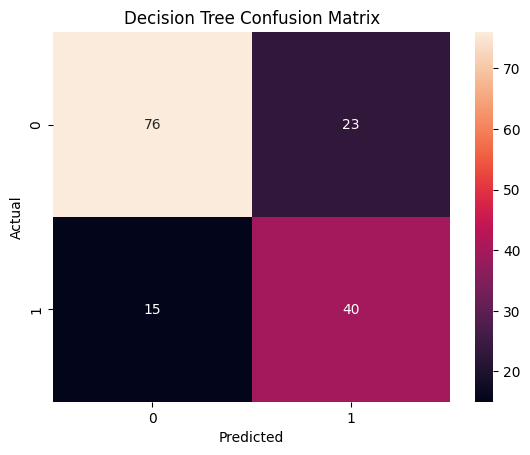

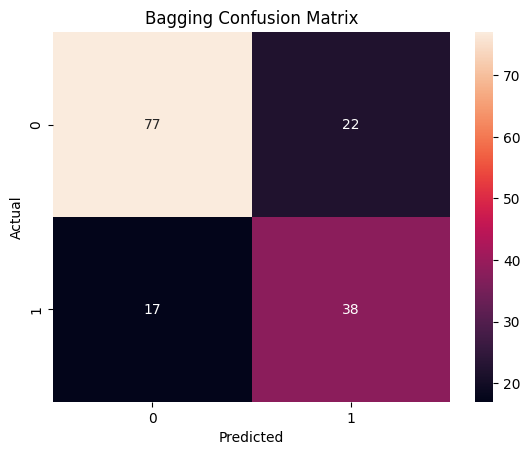

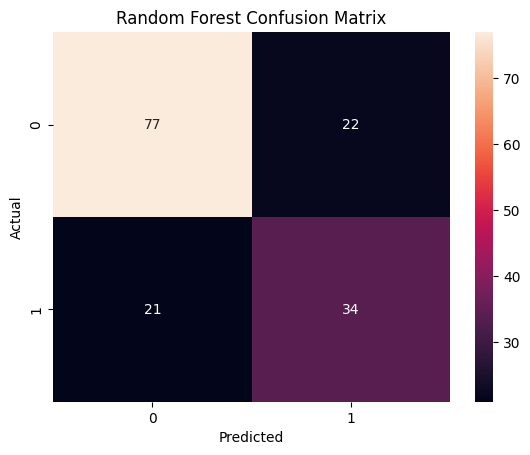

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d')
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

cm_bag = confusion_matrix(y_test, y_pred_bag)
sns.heatmap(cm_bag, annot=True, fmt='d')
plt.title("Bagging Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

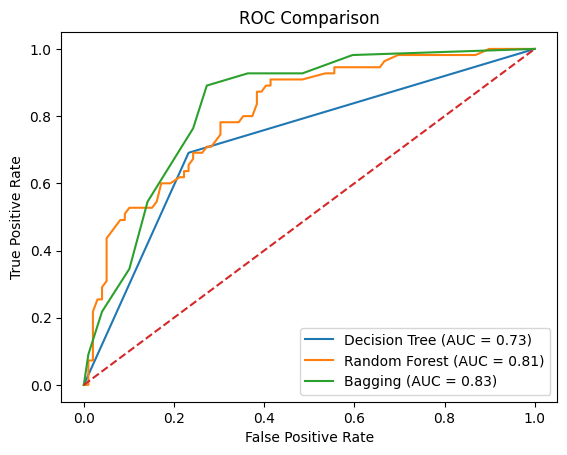

In [12]:
from sklearn.metrics import roc_curve, auc
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier

models = {
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Bagging": BaggingClassifier()
}

plt.figure()

for name, model in models.items():
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Comparison')
plt.legend()
plt.show()

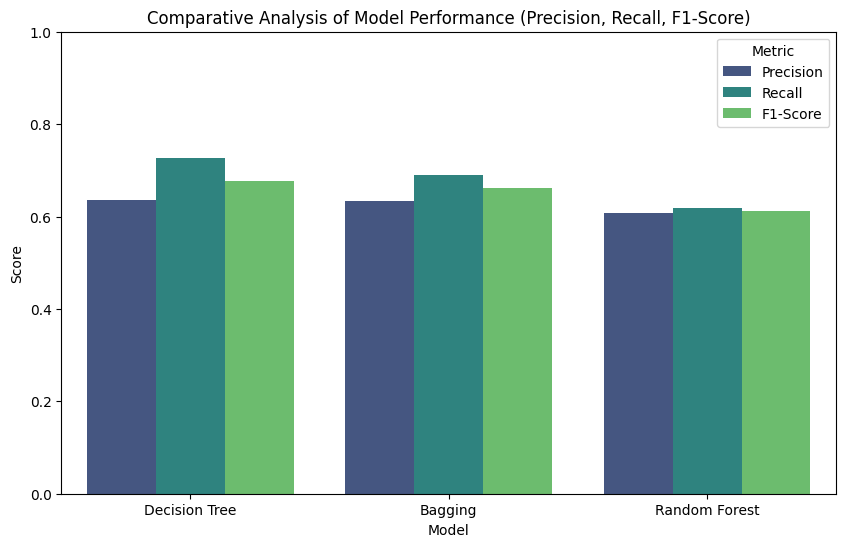

In [15]:
from sklearn.metrics import classification_report


report_dt = classification_report(y_test, y_pred_dt, output_dict=True)
report_bag = classification_report(y_test, y_pred_bag, output_dict=True)
report_rf = classification_report(y_test, y_pred_rf, output_dict=True)


metrics_data = {
    'Model': ['Decision Tree', 'Bagging', 'Random Forest'],
    'Precision': [report_dt['1']['precision'], report_bag['1']['precision'], report_rf['1']['precision']],
    'Recall': [report_dt['1']['recall'], report_bag['1']['recall'], report_rf['1']['recall']],
    'F1-Score': [report_dt['1']['f1-score'], report_bag['1']['f1-score'], report_rf['1']['f1-score']]
}

metrics_df = pd.DataFrame(metrics_data)

metrics_df_melted = metrics_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Score', hue='Metric', data=metrics_df_melted, palette='viridis')
plt.title('Comparative Analysis of Model Performance (Precision, Recall, F1-Score)')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.show()

In [14]:
import pickle
import os

model_dir = 'trained_models'
os.makedirs(model_dir, exist_ok=True)

with open(os.path.join(model_dir, 'decision_tree_classifier.pkl'), 'wb') as f:
    pickle.dump(DT, f)

print("Decision Tree Classifier saved as 'decision_tree_classifier.pkl'")

with open(os.path.join(model_dir, 'random_forest_classifier.pkl'), 'wb') as f:
    pickle.dump(RF, f)

print("Random Forest Classifier saved as 'random_forest_classifier.pkl'")

with open(os.path.join(model_dir, 'bagging_classifier.pkl'), 'wb') as f:
    pickle.dump(bagging_classifier, f)

print("Bagging Classifier saved as 'bagging_classifier.pkl'")

Decision Tree Classifier saved as 'decision_tree_classifier.pkl'
Random Forest Classifier saved as 'random_forest_classifier.pkl'
Bagging Classifier saved as 'bagging_classifier.pkl'
